## Installing and importing libraries

In [ ]:
# Install libraries
!pip install gensim
!pip install nltk
!pip install pyldavis
!pip install vegafusion
!pip install "vl-convert-python>=1.6.0"
!pip install gensim_models
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.5 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 14, in <module>
    from pip._vendor.certifi import where
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/certifi/__init__.py", line 1, in <module>
    from .core import contents, where
  File "/usr/local/li

In [ ]:
# Import and init
import pandas as pd
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
import gensim.corpora as corpora
from gensim.models import LdaModel
import altair as alt
alt.data_transformers.enable("vegafusion")
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

# Stop words
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Warnings fix
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Initial discovery

In [ ]:
df = pd.read_csv('AirlineReviews.csv')
print(df.head(0))

Empty DataFrame
Columns: [Aircraft, AirlineName, CabinType, DateFlown, DatePub, EntertainmentRating, FoodRating, GroundServiceRating, OriginCountry, OverallScore, Recommended, Review, Route, SeatComfortRating, ServiceRating, Slug, Title, TravelType, TripVerified, ValueRating, WifiRating, unique_id]
Index: []

[0 rows x 22 columns]


In [ ]:
df.dtypes

,0
Aircraft,object
AirlineName,object
CabinType,object
DateFlown,object
DatePub,object
EntertainmentRating,int64
FoodRating,int64
GroundServiceRating,int64
OriginCountry,object
OverallScore,float64


In [ ]:
df.isna().sum()

,0
Aircraft,93032
AirlineName,0
CabinType,3018
DateFlown,38462
DatePub,0
EntertainmentRating,0
FoodRating,0
GroundServiceRating,0
OriginCountry,1678
OverallScore,4331


#### Checking NA Values
- Review (corpus) : 824 NA
- Recommended (target) : 0 NA



In [ ]:
# Dropping NA in 'Review' column and subset into new dataframe
df_clean = df.dropna(subset=['Review']).copy()

#### Recommendation Distribution Yes/No

In [ ]:
barchart_Recommended = alt.Chart(df).mark_bar().encode(
    x=alt.X('Recommended:N', title='Passenger Recommendation'),
    y=alt.Y('count()', title='Number of Reviews'),
    color=alt.Color('Recommended:N',
                    scale=alt.Scale(domain=['no', 'yes'],
                                   range=['#e74c3c', '#2ecc71']))
).properties(
    title='Distribution of Recommendations',
    width=400
)

barchart_Recommended

alt.Chart(...)

### Text Preprocessing

In [ ]:
# Push raw reviews into list
docs = df_clean['Review'].tolist()

In [ ]:
# Cleaning function
def clean_doc(doc):
    no_punct = ''.join([c for c in doc if c not in string.punctuation])
    words = no_punct.lower().split()
    final_words = [word for word in words if word not in stop_words]
    final_words = [word for word in final_words if len(word) > 2]
    return final_words

In [ ]:
# Apply the cleaning to the raw Reviews
cleaned_docs = [clean_doc(doc) for doc in docs]

In [ ]:
# Create ID Index
id2word = corpora.Dictionary(cleaned_docs)

corpus = [id2word.doc2bow(text) for text in cleaned_docs]

In [103]:
# Check outputs
print(cleaned_docs[0])
print(corpus[0])


['moroni', 'moheli', 'turned', 'pretty', 'decent', 'airline', 'online', 'booking', 'worked', 'well', 'checkin', 'boarding', 'fine', 'looked', 'well', 'maintained', 'short', 'minutes', 'didnt', 'expect', 'much', 'still', 'managed', 'hand', 'bottle', 'water', 'biscuits', 'though', 'nice', 'time']
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 2), (28, 1)]


In [104]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	airline
1	biscuits
2	boarding
3	booking
4	bottle
5	checkin
6	decent
7	didnt
8	expect
9	fine
10	hand
11	looked
12	maintained
13	managed
14	minutes
15	moheli
16	moroni
17	much
18	nice
19	online
20	pretty
21	short
22	still
23	though
24	time
25	turned
26	water
27	well
28	worked


### LDA Models

### 10 Topic Model

In [ ]:
numTopics = 10


In [62]:
from gensim.models import LdaMulticore

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=numTopics,
    random_state=100,
    chunksize=5000,
    passes=5,
    per_word_topics=True,
    workers = None
)

In [122]:
from gensim.models.coherencemodel import CoherenceModel
# Coherence Scores for 10 Topic Model
coherence_model10 = CoherenceModel(model=lda_model,
                                 texts=cleaned_docs,
                                 dictionary=id2word,
                                 coherence='c_v')
coherence_10 = coherence_model10.get_coherence()

print(coherence_10)

0.39328775520016734


#### 10 Topic Model Coherence Score: 0.393

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

topic_data10 = []
for topic_id in range(10):
    topic_terms = lda_model.show_topic(topic_id, topn=10)
    for word, prob in topic_terms:
        topic_data10.append({
            'Model': '10 Topics',
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })
df_topics_words10 = pd.DataFrame(topic_data10)

In [118]:
# Topics & their keywords
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.015*"service" + 0.014*"class" + 0.013*"good" + 0.012*"business" + 0.012*"food" + 0.011*"seat" + 0.010*"economy" + 0.009*"seats" + 0.009*"time" + 0.007*"crew"

Topic: 1 
Words: 0.018*"crew" + 0.016*"good" + 0.015*"food" + 0.014*"cabin" + 0.011*"service" + 0.010*"time" + 0.009*"entertainment" + 0.008*"staff" + 0.008*"friendly" + 0.007*"served"

Topic: 2 
Words: 0.008*"seat" + 0.008*"time" + 0.007*"staff" + 0.007*"one" + 0.007*"back" + 0.007*"could" + 0.006*"asked" + 0.006*"told" + 0.006*"passengers" + 0.006*"crew"

Topic: 3 
Words: 0.014*"time" + 0.011*"airline" + 0.011*"airlines" + 0.010*"bag" + 0.007*"one" + 0.007*"check" + 0.007*"bags" + 0.006*"never" + 0.006*"get" + 0.006*"service"

Topic: 4 
Words: 0.018*"boarding" + 0.016*"gate" + 0.013*"time" + 0.010*"minutes" + 0.010*"passengers" + 0.008*"departure" + 0.007*"hour" + 0.007*"airport" + 0.007*"check" + 0.007*"hours"

Topic: 5 
Words: 0.021*"seats" + 0.016*"seat" + 0.010*"airline" + 0.007*"staff" + 0.006*"food" + 0

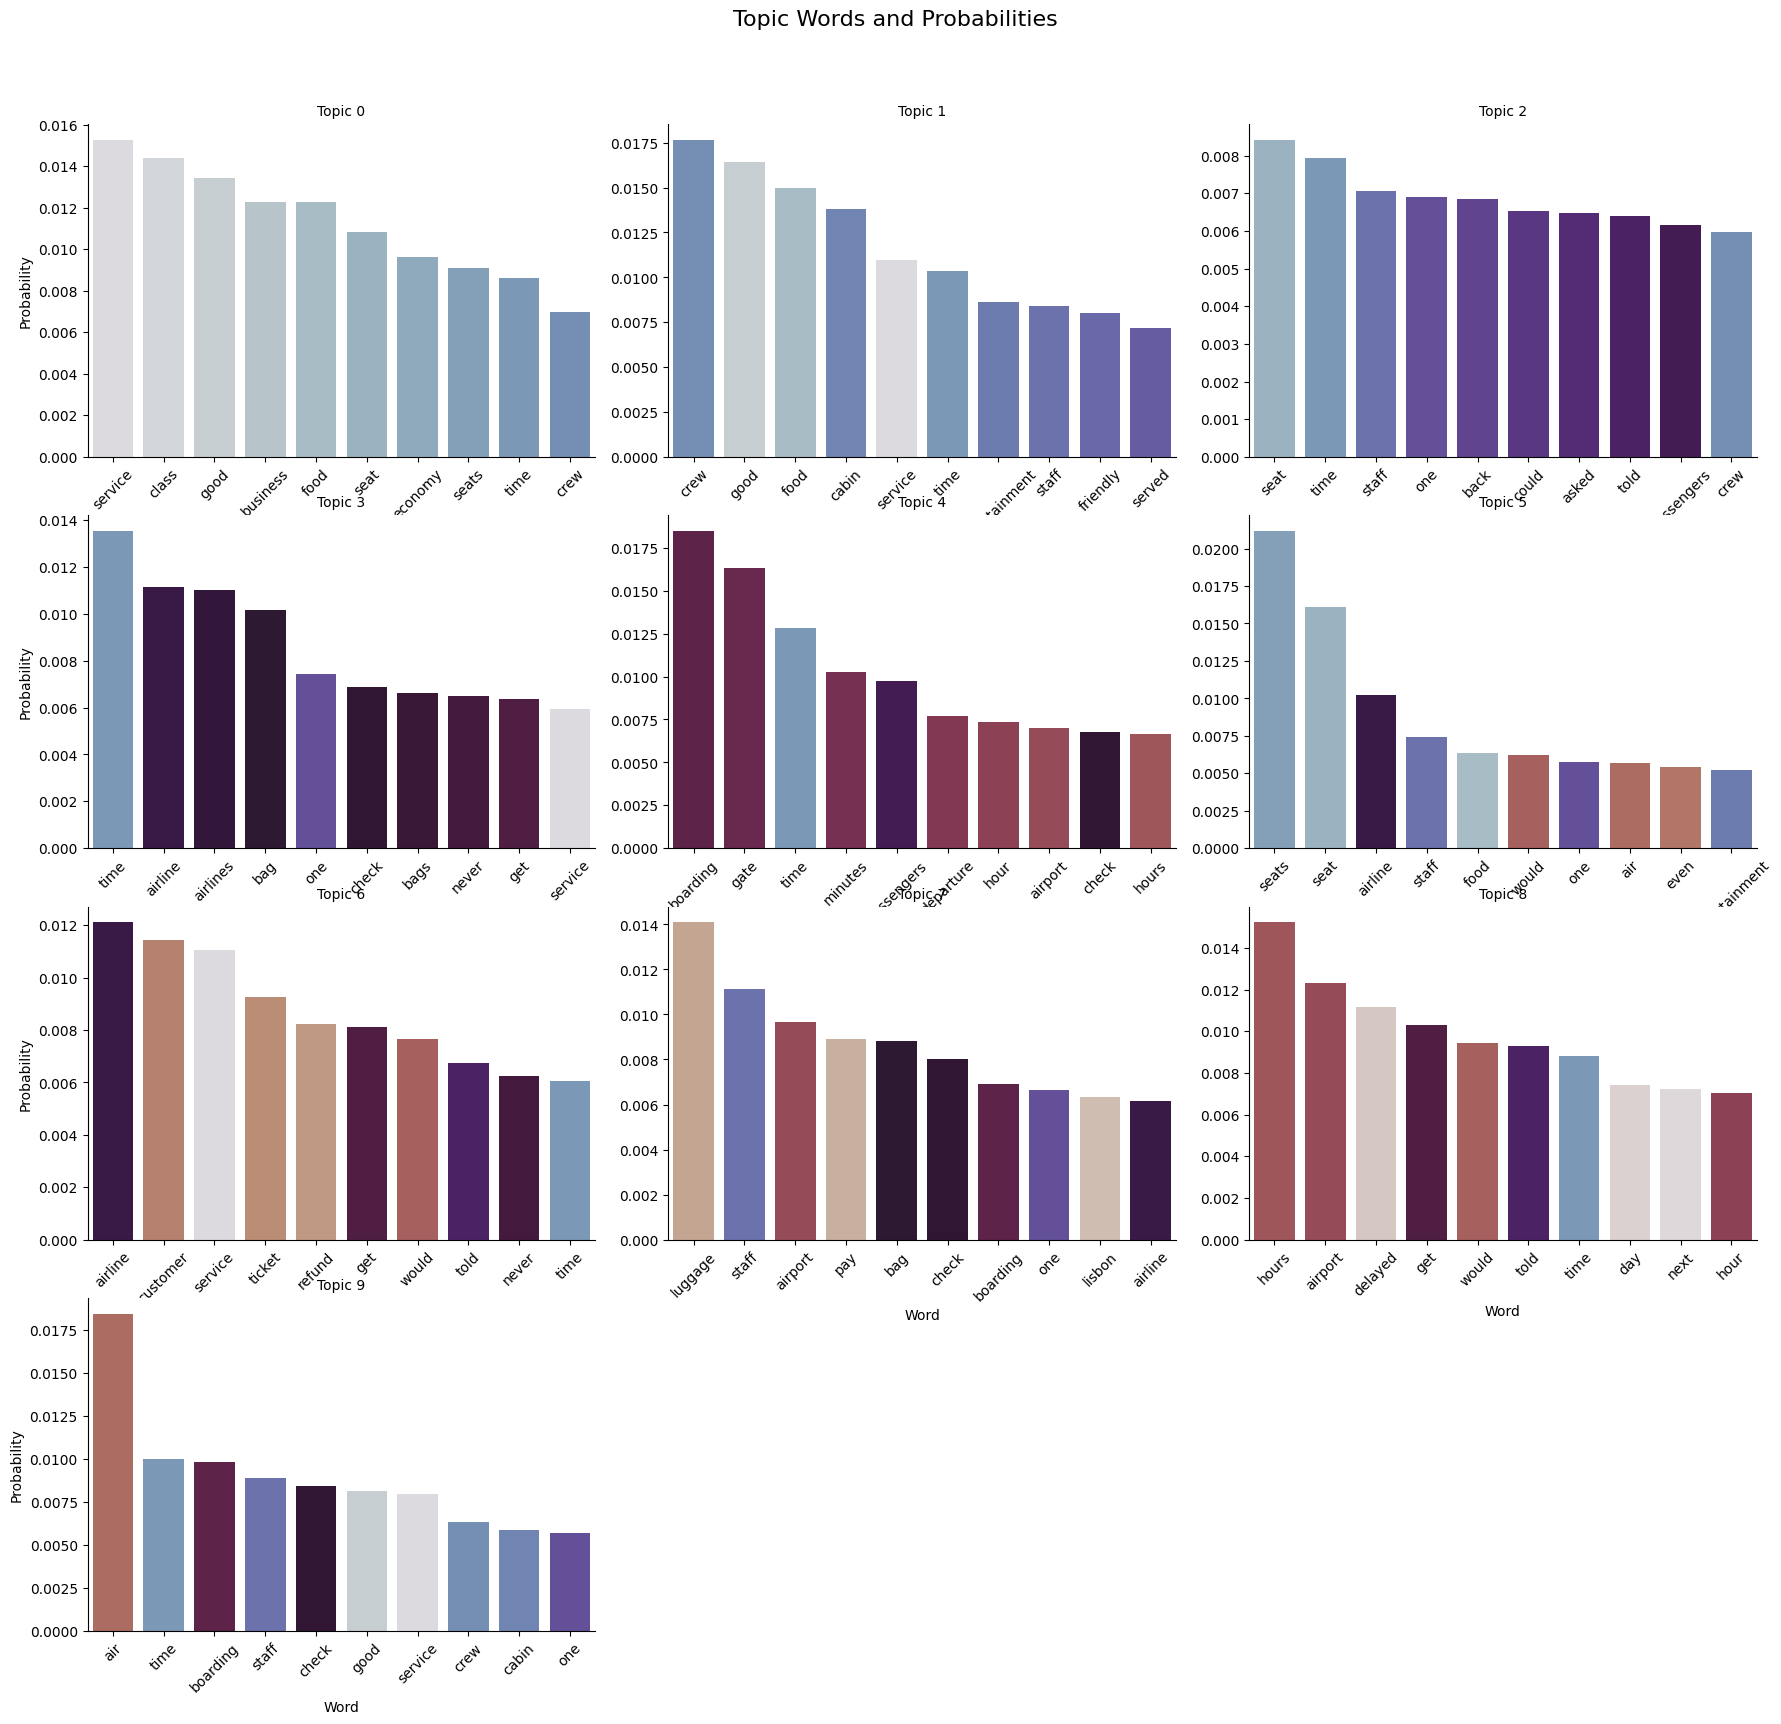

In [71]:
# Bar Plot: 10 Topics & Terms
g = sns.catplot(data=df_topics_words10, x='Word', y='Probability', col='Topic ID',
                col_wrap=3, kind='bar', height=4, aspect=1.5, hue='Word',
                legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Topic Words and Probabilities', y=1.05, fontsize=16)
plt.show()


In [72]:
vis10 = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word, mds="mmds", R=30)
vis10

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.124591  0.042392       1        1  16.719643
0      0.134037 -0.054469       2        1  16.651128
6     -0.100751  0.121546       3        1  14.189718
1      0.116698 -0.113222       4        1  12.973522
5      0.078608  0.031351       5        1   8.902228
3      0.013439  0.094456       6        1   8.453312
2     -0.019072  0.051709       7        1   6.556944
4     -0.044316 -0.076299       8        1   5.676379
7     -0.075999 -0.037368       9        1   4.941227
9      0.021948 -0.060096      10        1   4.935899, topic_info=         Term          Freq         Total Category  logprob  loglift
2    boarding  30018.000000  30018.000000  Default  30.0000  30.0000
46       good  48212.000000  48212.000000  Default  29.0000  29.0000
577      gate  22106.000000  22106.000000  Default  28.0000  28.0000
179       air  27512.000000  27512.000000  Default  27.0000  27.0000
103     seats  49382.000000  49382.000000  Default  26.0000  26.0000
..        ...           ...           ...      ...      ...      ...
527     great   1320.261809  18647.860323  Topic10  -5.7553   0.3607
123      late   1262.865111  16882.303305  Topic10  -5.7997   0.4158
294   luggage   1350.844201  25378.799488  Topic10  -5.7324   0.0755
366      even   1332.941752  34309.449663  Topic10  -5.7457  -0.2394
96       hour   1269.014348  29851.784677  Topic10  -5.7948  -0.1494

[1017 rows x 6 columns], token_table=       Topic      Freq       Term
term                             
27910      2  0.051660       0905
27910      6  0.051660       0905
27910      8  0.878217       0905
68386      8  0.907558       0940
3514       1  0.807331       1030
...      ...       ...        ...
60004      6  0.925342  “personal
17099      1  0.917075  “weather”
17099      3  0.020843  “weather”
17099      6  0.041685  “weather”
17099      8  0.020843  “weather”

[4951 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 1, 7, 2, 6, 4, 3, 5, 8, 10])

### 5 Topics Model

In [83]:
from gensim.models import LdaMulticore

lda_model_5 = LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=5,
    random_state=100,
    chunksize=5000,
    passes=5,
    per_word_topics=True,
    workers = None
)

In [123]:
# Coherence Scores for 5 Topic Model
coherence_model5 = CoherenceModel(model=lda_model_5,
                                 texts=cleaned_docs,
                                 dictionary=id2word,
                                 coherence='c_v')
coherence_5 = coherence_model5.get_coherence()

print(coherence_5)

0.4251179361582843


#### 5 Topic Model Coherence Score: 0.425

In [106]:
topic_data_5 = []
for topic_id in range(5):
    topic_terms = lda_model_5.show_topic(topic_id, topn=10)
    for word, prob in topic_terms:
        topic_data_5.append({
            'Model': '5 Topics',
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words_5 = pd.DataFrame(topic_data_5)

# Check columns
print(df_topic_words_5.columns)
print(df_topic_words_5.head())

Index(['Model', 'Topic ID', 'Word', 'Probability'], dtype='object')
      Model  Topic ID     Word  Probability
0  5 Topics         0  service     0.013315
1  5 Topics         0     seat     0.012061
2  5 Topics         0     good     0.011967
3  5 Topics         0    class     0.011488
4  5 Topics         0     food     0.010932


In [119]:
# 5 Topics & their keywords
for idx, topic in lda_model_5.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.013*"service" + 0.012*"seat" + 0.012*"good" + 0.011*"class" + 0.011*"food" + 0.011*"seats" + 0.009*"business" + 0.009*"time" + 0.008*"economy" + 0.006*"crew"

Topic: 1 
Words: 0.014*"crew" + 0.012*"food" + 0.012*"good" + 0.011*"cabin" + 0.009*"time" + 0.009*"service" + 0.008*"staff" + 0.007*"entertainment" + 0.006*"seats" + 0.006*"meal"

Topic: 2 
Words: 0.009*"hours" + 0.009*"told" + 0.009*"get" + 0.008*"would" + 0.008*"airport" + 0.008*"time" + 0.007*"service" + 0.007*"airline" + 0.007*"back" + 0.006*"customer"

Topic: 3 
Words: 0.012*"airline" + 0.010*"time" + 0.008*"airlines" + 0.008*"get" + 0.008*"service" + 0.007*"never" + 0.007*"hours" + 0.007*"one" + 0.006*"customer" + 0.006*"airport"

Topic: 4 
Words: 0.011*"boarding" + 0.009*"check" + 0.008*"airport" + 0.008*"seats" + 0.008*"time" + 0.007*"would" + 0.007*"gate" + 0.007*"ticket" + 0.006*"staff" + 0.006*"told"



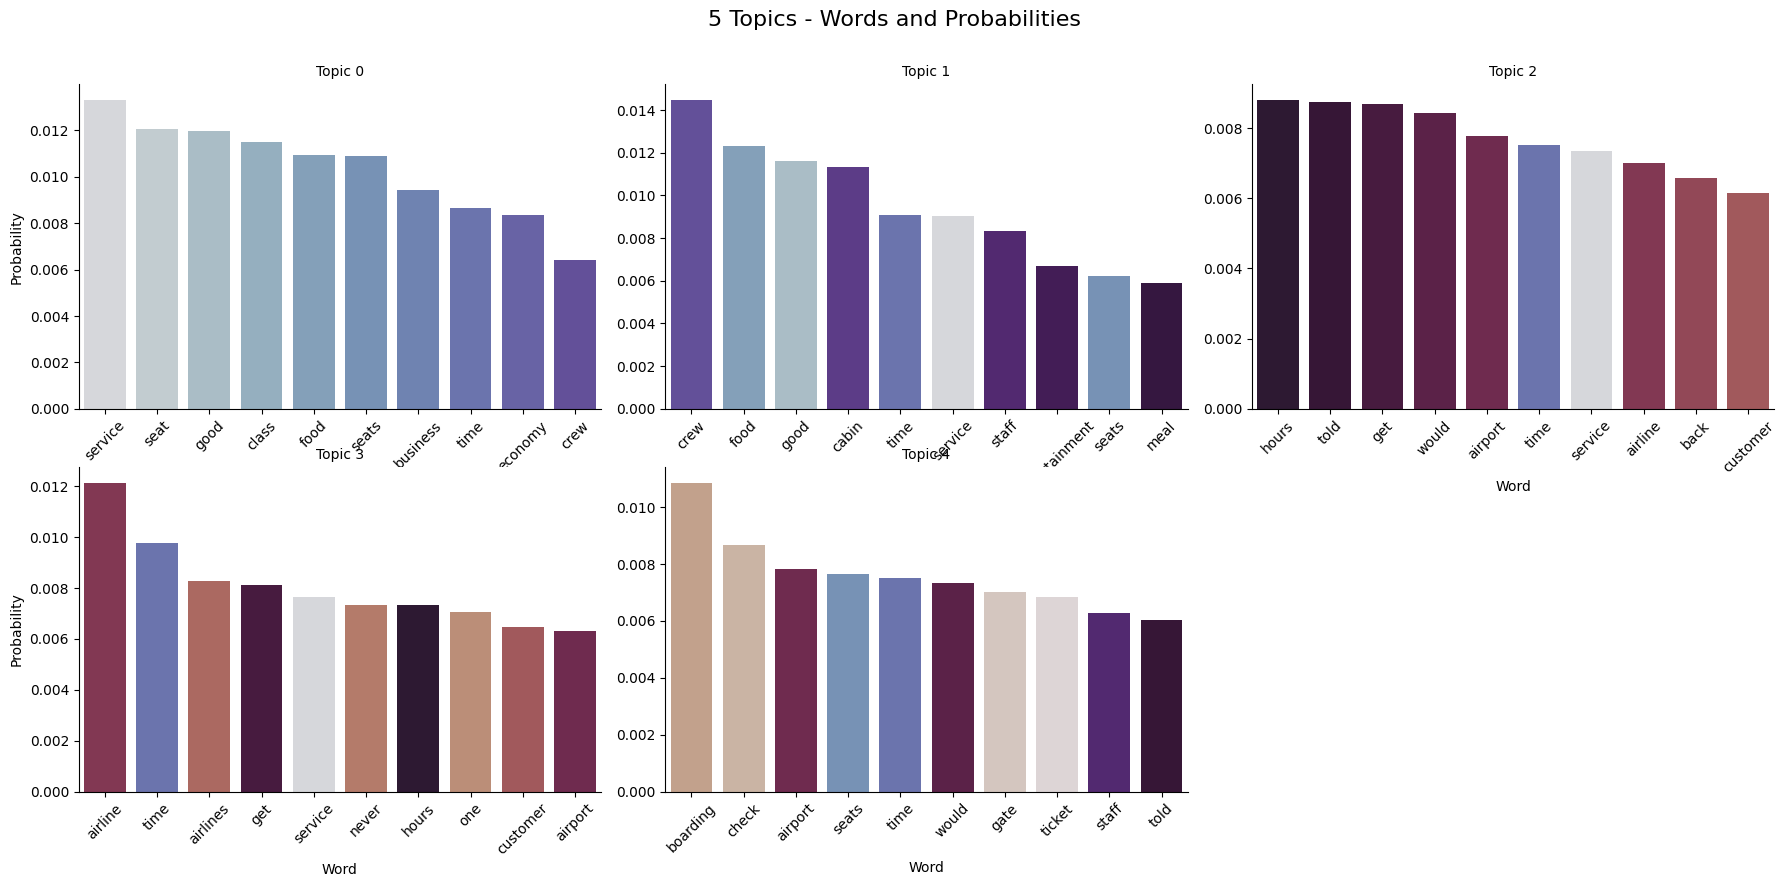

In [135]:
# Bar Plot: 5 Topics & Terms
g = sns.catplot(data=df_topic_words_5, x='Word', y='Probability', col='Topic ID',
                col_wrap=3, kind='bar', height=4, aspect=1.5, hue='Word',
                legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('5 Topics - Words and Probabilities', y=1.05, fontsize=16)
plt.show()

In [161]:
vis5 = pyLDAvis.gensim_models.prepare(lda_model_5, corpus, id2word, mds="tsne", R=30)
vis5

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
0      53.244572  62.172466       1        1  24.374072
2      47.122005 -93.033188       2        1  23.665046
3     -18.902380   8.376451       3        1  20.440299
1     -44.873154 -77.738747       4        1  18.883515
4      98.307274 -19.391212       5        1  12.637068, topic_info=       Term          Freq         Total Category  logprob  loglift
46     good  48687.000000  48687.000000  Default  30.0000  30.0000
620    food  48554.000000  48554.000000  Default  29.0000  29.0000
152    crew  43406.000000  43406.000000  Default  28.0000  28.0000
69    cabin  34126.000000  34126.000000  Default  27.0000  27.0000
653   class  31544.000000  31544.000000  Default  26.0000  26.0000
..      ...           ...           ...      ...      ...      ...
43    could   4430.834235  30450.695434   Topic5  -5.4846   0.1410
288     get   4916.711886  45447.099445   Topic5  -5.3805  -0.1554
96     hour   4301.099952  29442.202586   Topic5  -5.5143   0.1450
366    even   4349.930028  34140.071459   Topic5  -5.5030   0.0082
102  return   4087.655547  26882.056502   Topic5  -5.5652   0.1850

[542 rows x 6 columns], token_table=       Topic      Freq    Term
term                          
25634      1  0.948911   1x2x1
25634      3  0.013556   1x2x1
25634      4  0.027112   1x2x1
60770      5  0.898375  200eur
4799       1  0.030688    2020
...      ...       ...     ...
8808       1  0.062143     €40
8808       5  0.932150     €40
34319      2  0.044743     €55
34319      3  0.044743     €55
34319      5  0.894861     €55

[1670 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 3, 4, 2, 5])

### 7 Topics Model

In [108]:
lda_model_7 = LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=7,
    random_state=100,
    chunksize=5000,
    passes=5,
    per_word_topics=True,
    workers = None
)

In [124]:
from gensim.models.coherencemodel import CoherenceModel
# Coherence Scores for 7 Topic Model
coherence_model_7 = CoherenceModel(model=lda_model_7,
                                 texts=cleaned_docs,
                                 dictionary=id2word,
                                 coherence='c_v')
coherence_7 = coherence_model_7.get_coherence()
print(coherence_7)

0.4052913521841962


#### 7 Topic Model Coherence Score: 0.405



In [113]:
topic_data_7 = []
for topic_id in range(7):
    topic_terms = lda_model_7.show_topic(topic_id, topn=10)
    for word, prob in topic_terms:
        topic_data_7.append({
            'Model': '7 Topics',
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })
df_topic_words_7 = pd.DataFrame(topic_data_7)

In [120]:
# 7 Topics & their keywords
for idx, topic in lda_model_7.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.015*"service" + 0.014*"good" + 0.012*"class" + 0.012*"food" + 0.010*"seat" + 0.010*"time" + 0.010*"business" + 0.009*"seats" + 0.008*"economy" + 0.007*"crew"

Topic: 1 
Words: 0.016*"crew" + 0.013*"food" + 0.013*"good" + 0.013*"cabin" + 0.010*"service" + 0.009*"time" + 0.008*"staff" + 0.007*"entertainment" + 0.006*"served" + 0.006*"meal"

Topic: 2 
Words: 0.009*"time" + 0.009*"hours" + 0.008*"staff" + 0.008*"told" + 0.008*"airport" + 0.008*"would" + 0.007*"get" + 0.007*"back" + 0.007*"delayed" + 0.006*"luggage"

Topic: 3 
Words: 0.012*"time" + 0.009*"hours" + 0.009*"delayed" + 0.009*"airline" + 0.008*"get" + 0.008*"airport" + 0.008*"airlines" + 0.007*"one" + 0.007*"hour" + 0.006*"bag"

Topic: 4 
Words: 0.016*"boarding" + 0.011*"gate" + 0.010*"time" + 0.009*"check" + 0.008*"airport" + 0.008*"passengers" + 0.007*"minutes" + 0.007*"would" + 0.007*"hours" + 0.007*"staff"

Topic: 5 
Words: 0.016*"seats" + 0.014*"seat" + 0.010*"airline" + 0.009*"staff" + 0.008*"air" + 0.00

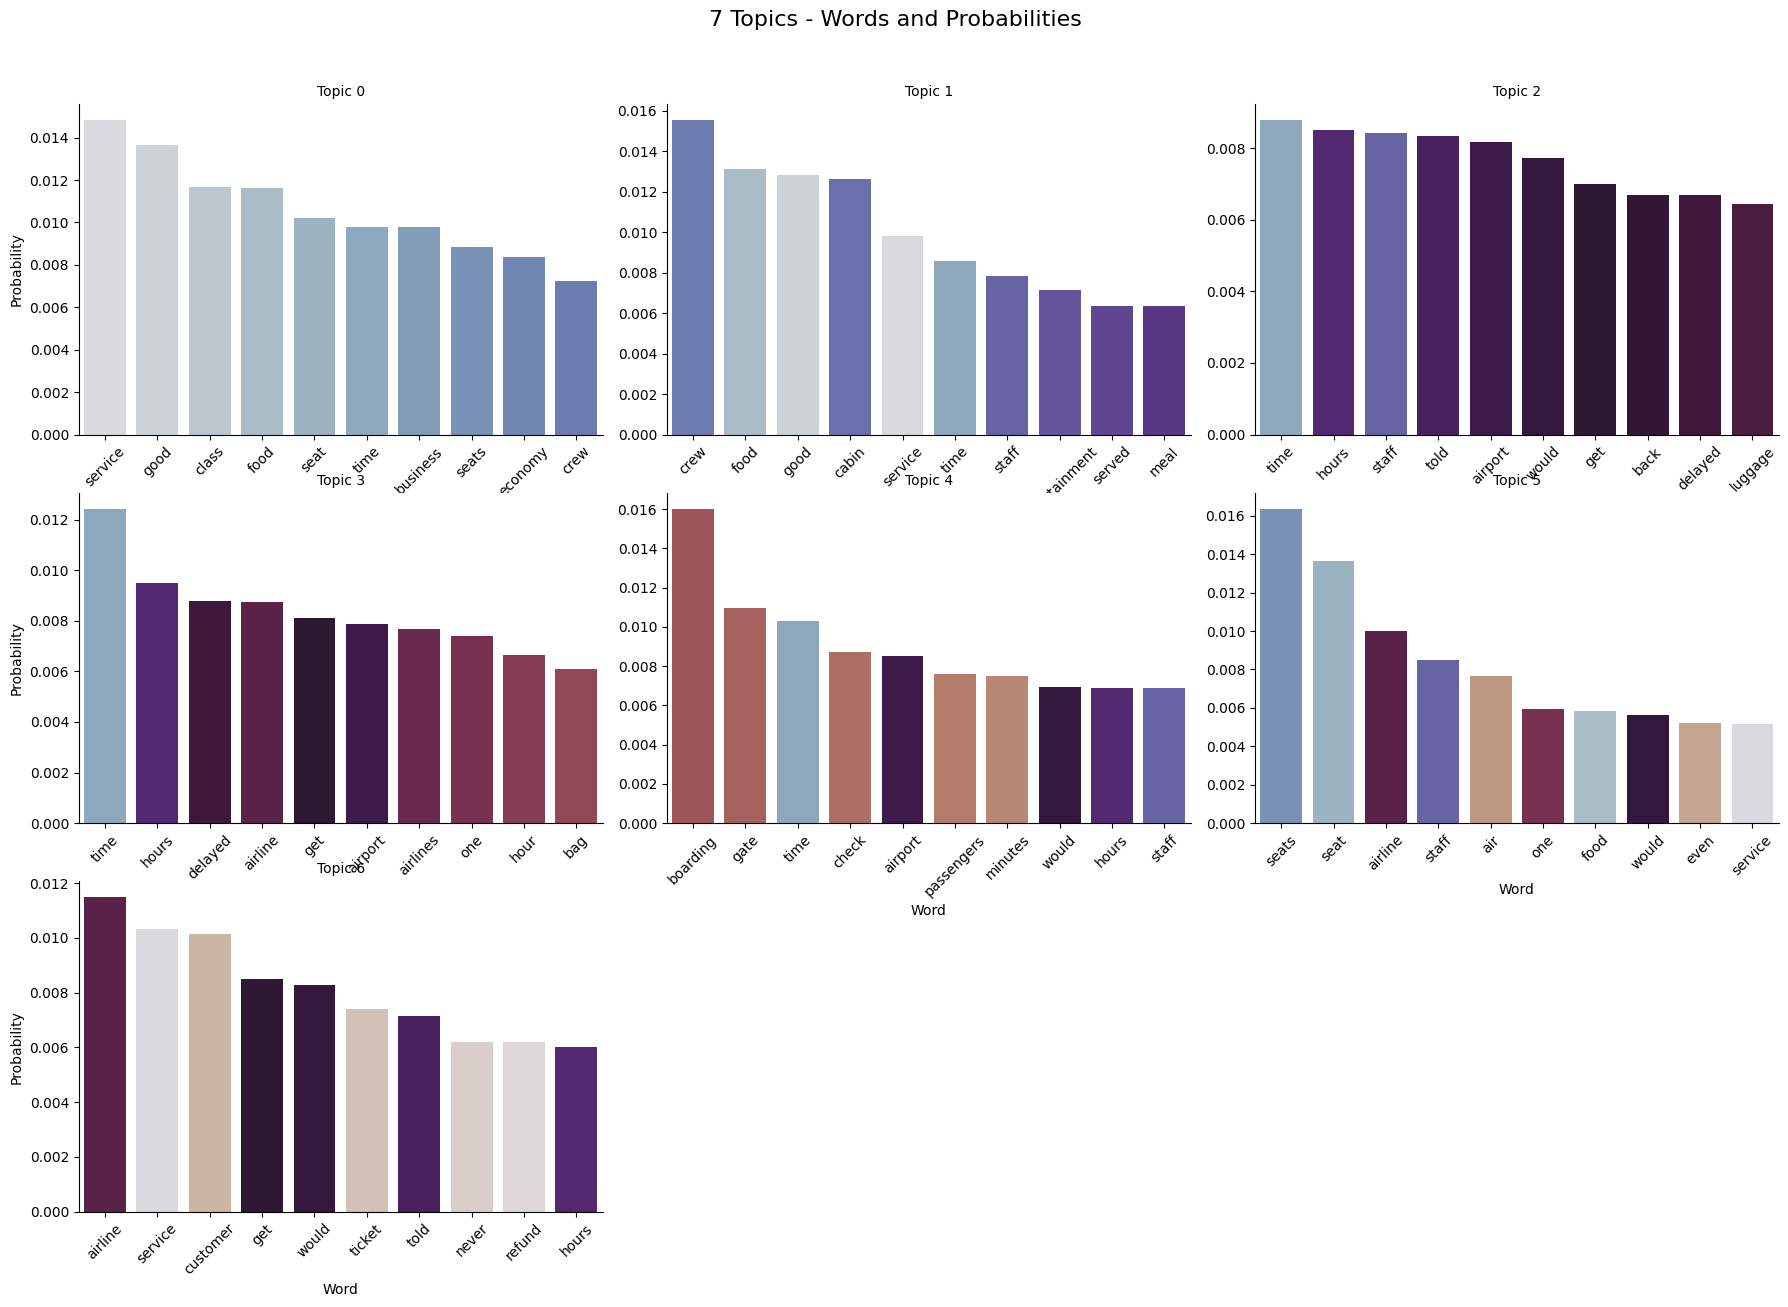

In [114]:
# Bar Plot: 7 Topics & Terms
g = sns.catplot(data=df_topic_words_7, x='Word', y='Probability', col='Topic ID',
                col_wrap=3, kind='bar', height=4, aspect=1.5, hue='Word',
                legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('7 Topics - Words and Probabilities', y=1.05, fontsize=16)
plt.show()

In [117]:
vis7 = pyLDAvis.gensim_models.prepare(lda_model_7, corpus, id2word, mds="mmds", R=30)
vis7

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.025924 -0.114208       1        1  19.669414
6      0.084863  0.095938       2        1  18.970619
3      0.043933  0.050830       3        1  15.201296
1     -0.084331 -0.088510       4        1  14.271647
2     -0.003969  0.071109       5        1  12.072369
5      0.031504 -0.048130       6        1  11.300576
4     -0.046075  0.032971       7        1   8.514079, topic_info=         Term          Freq         Total Category  logprob  loglift
2    boarding  29360.000000  29360.000000  Default  30.0000  30.0000
46       good  47972.000000  47972.000000  Default  29.0000  29.0000
577      gate  21761.000000  21761.000000  Default  28.0000  28.0000
103     seats  49573.000000  49573.000000  Default  27.0000  27.0000
152      crew  42968.000000  42968.000000  Default  26.0000  26.0000
..        ...           ...           ...      ...      ...      ...
103     seats   3505.685344  49573.733421   Topic7  -5.3239  -0.1856
288       get   3177.052024  45555.157612   Topic7  -5.4223  -0.1995
102    return   2761.510127  26941.769808   Topic7  -5.5625   0.1855
0     airline   3018.509887  57933.834035   Topic7  -5.4735  -0.4911
364   delayed   2684.114606  27494.029108   Topic7  -5.5909   0.1368

[715 rows x 6 columns], token_table=       Topic      Freq   Term
term                         
25634      1  0.910724  1x2x1
25634      3  0.014689  1x2x1
25634      4  0.029378  1x2x1
25634      5  0.014689  1x2x1
25634      6  0.014689  1x2x1
...      ...       ...    ...
14125      3  0.066985    €35
14125      7  0.870809    €35
8808       2  0.073897    €40
8808       7  0.886764    €40
34319      2  0.916998    €55

[2768 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 4, 2, 3, 6, 5])

## Coherence Scores Compared

In [128]:
coh_data = {
    'Number of Topics' : ['5-Topic', '7-Topic', '10-Topic'],
    'Coherence Score': [0.425, 0.405, 0.393]
}

df_coherence = pd.DataFrame(coh_data)

(0.0, 0.5)

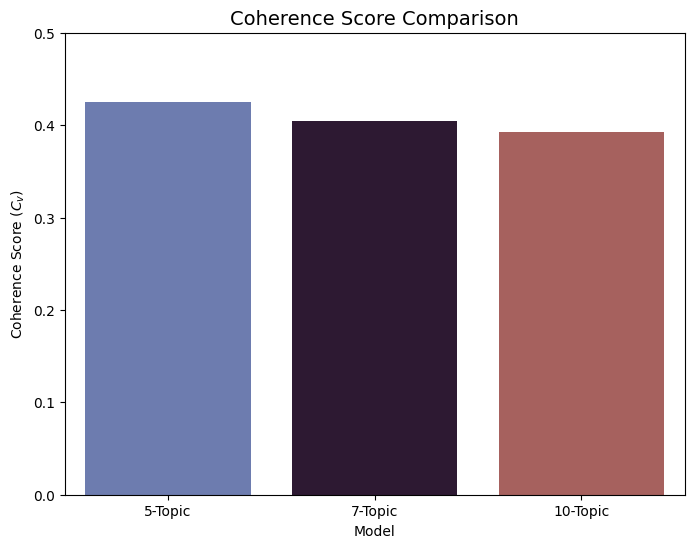

In [132]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_coherence,
    x='Number of Topics',
    y='Coherence Score',
    palette='twilight',
    hue='Number of Topics',
    legend=False
)

plt.ylabel('Coherence Score ($C_v$)')
plt.xlabel('Model')
plt.title('Coherence Score Comparison', fontsize=14)

plt.ylim(0, 0.5)

# Model Results: Labeled Topics and Terms

*topics indexed -1 (starting at 0)*

## 5 Topic Model (Best)
#### Coherence Score: 0.425

### Topic 0: Premium vs. Economy Class

##### service, seat, good, class, food, seats, business, time, economy, crew

### Topic 1: Inflight Soft Product & Hospitality

##### crew, food, good, cabin, time, service, staff, entertainment, seats, meal

### Topic 2: Onground Staff Communication/Feedback

##### hours, told, get, would, airport, time, service, airline, back, customer

### Topic 3: General Airline Reliability

##### airline, time, airlines, get, service, never, hours, one, customer, airport

### Topic 4: Preflight Logistics/Ground Services

##### boarding, check, airport, seats, time, would, gate, ticket, staff, told


---


## 7 Topic Model
#### Coherence Score: 0.405

### Topic 0: General Inflight Satisfaction

##### service, good, class, food, seat, time, business, seats, economy, crew

### Topic 1: Crew Performance & Amenities/Service

##### crew, food, good, cabin, service, time, staff, entertainment, served, meal

### Topic 2: Ground Disruptions & Luggage

##### time, hours, staff, told, airport, would, get, back, delayed, luggage

### Topic 3: Delay Logistics & On Time

##### time, hours, delayed, airline, get, airport, airlines, one, hour, bag

### Topic 4: Boarding & Gate Experience

##### boarding, gate, time, check, airport, passengers, minutes, would, hours, staff

### Topic 5: Cabin Features & Physical Amenities

##### seats, seat, airline, staff, air, one, food, would, even, service

### Topic 6: Customer Relations & Financial Claims

##### airline, service, customer, get, would, ticket, told, never, refund, hours


---


## 10 Topic Model
#### Coherence Score: 0.393
##### *Did not label*
### Topic 0
##### service, class, good, business, food, seat, economy, seats, time, crew

### Topic 1
##### crew, good, food, cabin, service, time, entertainment, staff, friendly, served

### Topic 2
##### seat, time, staff, one, back, could, asked, told, passengers, crew

### Topic 3
##### time, airline, airlines, bag, one, check, bags, never, get, service

### Topic 4
##### boarding, gate, time, minutes, passengers, departure, hour, airport, check, hours

### Topic 5
##### seats, seat, airline, staff, food, would, one, air, even, entertainment

### Topic 6
##### airline, customer, service, ticket, refund, get, would, told, never, time

### Topic 7
##### luggage, staff, airport, pay, bag, check, boarding, one, lisbon, airline

### Topic 8
##### hours, airport, delayed, get, would, told, time, day, next, hour

### Topic 9
##### air, time, boarding, staff, check, good, service, crew, cabin, one


# Notes

The model with the best results ended up being the 5-topic model. As K increased to 10 the topics seemed to be more vague and less disernable. The topic clusters had quite a bit of overlap, specifically in topics 2 & 4, staff interaction/boarding experience. Topics 1, 3, 5 stayed relatively distinct and had good seperation on the axis. Topics 9 and 10 were niche, harder to label.

The 7-topic model had a lower coherence (0.405) than 5 (0.425) and more than 10 (0.393). It improved upon 10 topics but remained a bit noisy.

The 5-topic model yielded the best coherence score (0.425) which was inbetween 7 and 10. At this K the topics remained clear and distinct and the score proves its consistency.

### Better Word Freq by Topic Chart

In [158]:
topic_data_5_top5 = []
for topic_id in range(5):
    topic_terms = lda_model_5.show_topic(topic_id, topn=3) # top 5 words rather than 10
    for word, prob in topic_terms:
        topic_data_5_top5.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })
df_top5_words = pd.DataFrame(topic_data_5_top5)

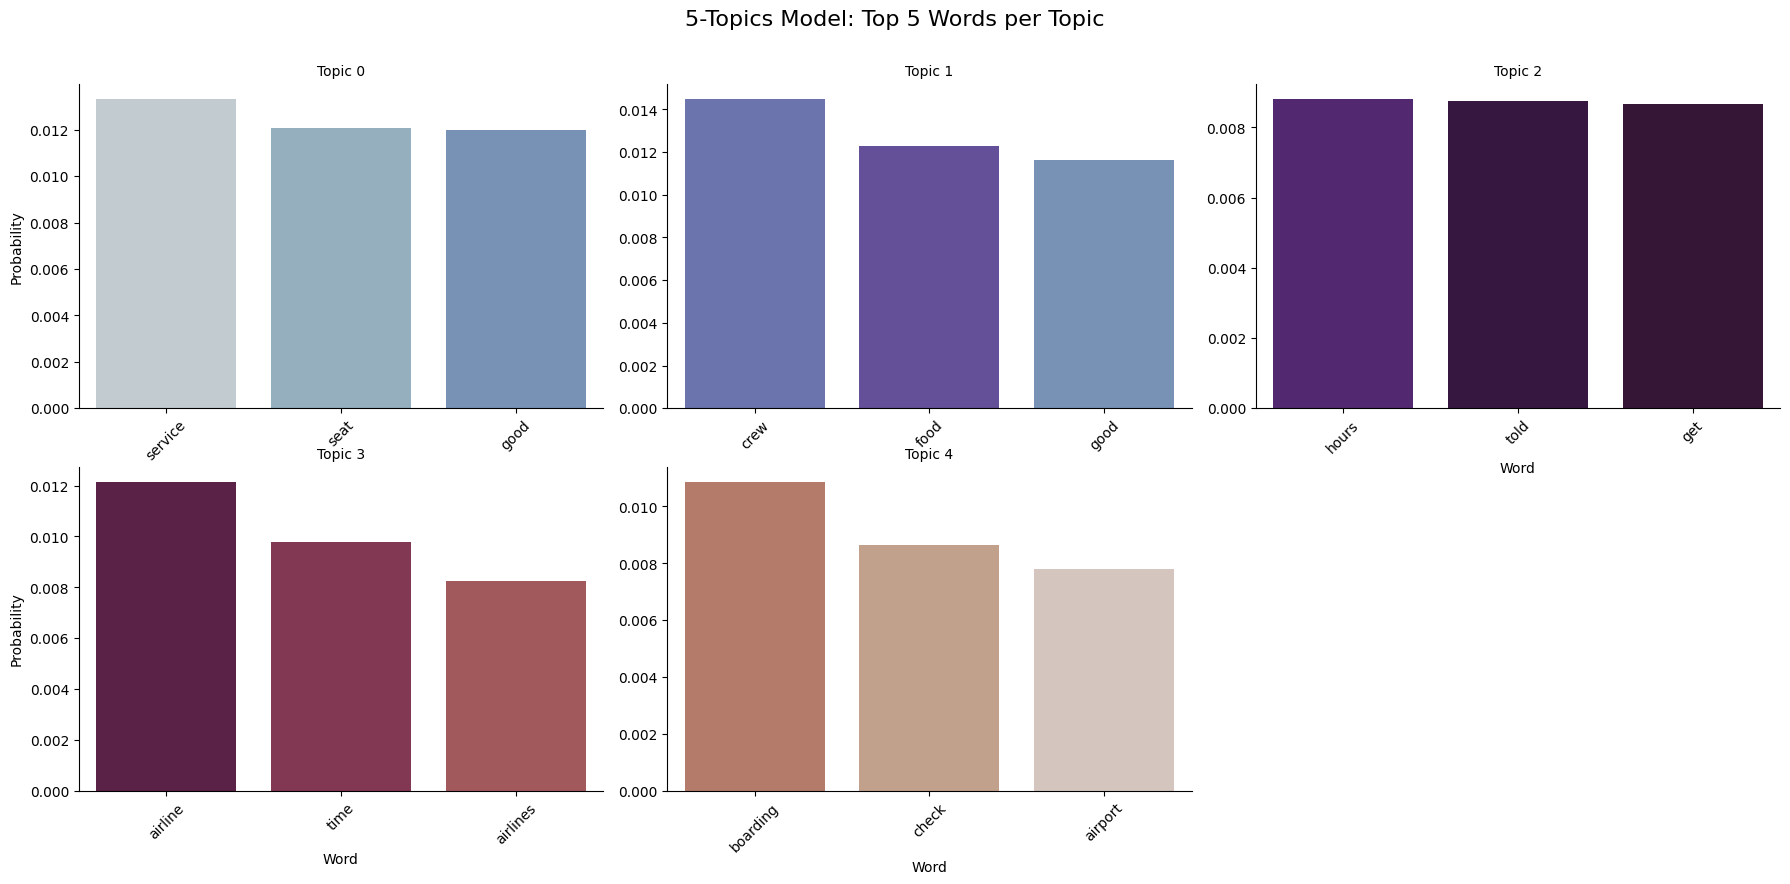

In [159]:
g = sns.catplot(data=df_top5_words, x='Word', y='Probability', col='Topic ID',
                col_wrap=3, kind='bar', height=4, aspect=1.5, hue='Word',
                legend=False, palette='twilight', sharex=False, sharey=False)

g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('5-Topics Model: Top 5 Words per Topic', y=1.05, fontsize=16)
plt.show()

## Most Common Topics of Reviews

In [150]:
# ASsign dominant topic to every review
def get_dominant_topic(bow):
    topic_probs = lda_model_5.get_document_topics(bow)
    dominant = sorted(topic_probs, key=lambda x: x[1], reverse=True)[0][0]
    return dominant
# Apply to corpus
topic_assignments = [get_dominant_topic(bow) for bow in corpus]


In [151]:
# Frequency dataframe
df_prevalence = pd.DataFrame(topic_assignments, columns=['Topic_ID'])

# Map Topic IDs to labels
topic_map = {
    0: "Premium/Economy Seating",
    1: "Inflight Service",
    2: "Staff Communication",
    3: "Carrier Reliability",
    4: "Pre flight Logistics"
}
df_prevalence['Topic'] = df_prevalence['Topic_ID'].map(topic_map)
prevalence_counts = df_prevalence['Topic'].value_counts(normalize=True).reset_index()
prevalence_counts.columns = ['Topic', 'Proportion']


/tmp/ipykernel_10303/2094368975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prevalence_counts,


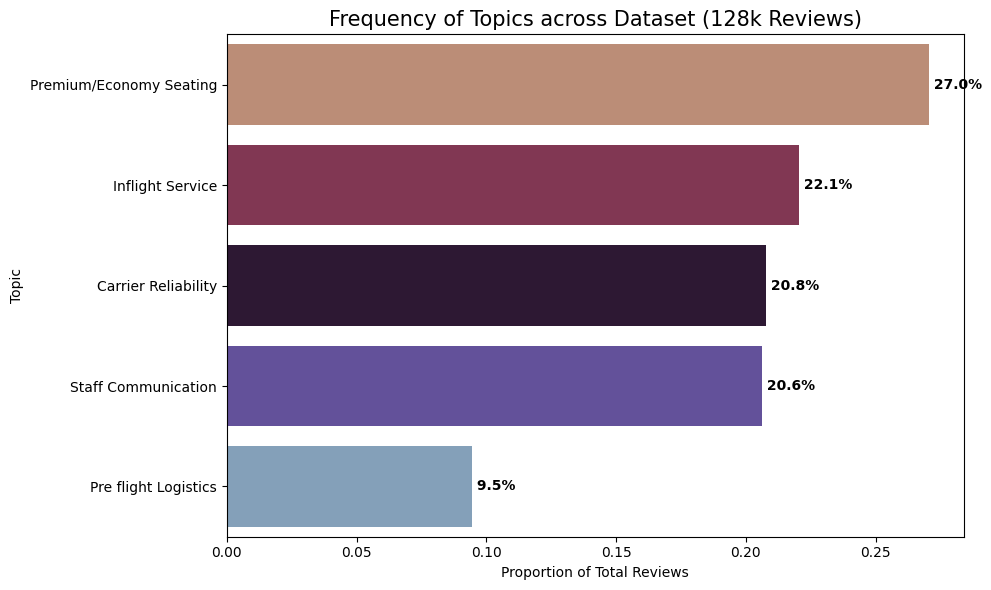

In [153]:

# Freq of Topics Across Dataset
plt.figure(figsize=(10, 6))
sns.barplot(data=prevalence_counts,
            x='Proportion',
            y='Topic',
            palette='twilight_r')

plt.title('Frequency of Topics across Dataset (128k Reviews)', fontsize=15)
plt.xlabel('Proportion of Total Reviews')
plt.ylabel('Topic')

# Percentage labels
for i, val in enumerate(prevalence_counts['Proportion']):
    plt.text(val, i, f' {val:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Machine Learning

In [162]:
df_final = df_clean.copy()
df_final['Recommended'] = df_final['Recommended'].str.lower().str.strip()

# Mapping 1 - "Yes" and 2 - "No"
df_final['Target'] = df_final['Recommended'].map({'yes': 1, 'no': 0})

# Deal with NULL values
df_final = df_final.dropna(subset=['Target'])

# Verify distribution
print(df_final['Target'].value_counts())


Target
0    77009
1    51622
Name: count, dtype: int64


### Train/Test

In [163]:
features = df_final['Review']
target = df_final['Target']

In [165]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Verify split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 102904 samples.
Testing set has 25727 samples.


In [166]:
# Convertin text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

preprocessing = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer())
])

train_preprocessed = preprocessing.fit_transform(X_train)
test_preprocessed = preprocessing.transform(X_test)

In [167]:
nb_classifier = MultinomialNB()
svm_classifier = LinearSVC(dual=False)
lr_classifier = LogisticRegression(max_iter=1000)
ada_classifier = AdaBoostClassifier(n_estimators=50, random_state=42)
random_classifier = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# Train each model
print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...
Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [168]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

# Compare the aaccuracy
print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.8641505033622264
SVM Accuracy: 0.9156139464375948
LR Accuracy: 0.9168577758774829
ADA Accuracy: 0.8459206281338671
RF Accuracy: 0.8887550044700121


## Model Accuracy Comparisons:

- NB Accuracy: 86%

- SVM Accuracy: 91%

- LR Accuracy: 92%

- ADA Accuracy: 85%

- RF Accuracy: 89%

### Classification Report

In [169]:
target_names = ['Not Recommended (0)', 'Recommended (1)']

print("Classification report for Logistic Regression):\n")
print(classification_report(y_test, lr_predictions, target_names=target_names))

Classification report for Logistic Regression):

                     precision    recall  f1-score   support

Not Recommended (0)       0.92      0.94      0.93     15340
    Recommended (1)       0.91      0.89      0.90     10387

           accuracy                           0.92     25727
          macro avg       0.91      0.91      0.91     25727
       weighted avg       0.92      0.92      0.92     25727



F1 Score - Recommended 90%

### Conf Matrix

In [170]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

In [171]:
conf_matrix = confusion_matrix(y_test, lr_predictions)

In [172]:
conf_matrix_df = pd.DataFrame(conf_matrix, index=['No', 'Yes'], columns=['No', 'Yes'])

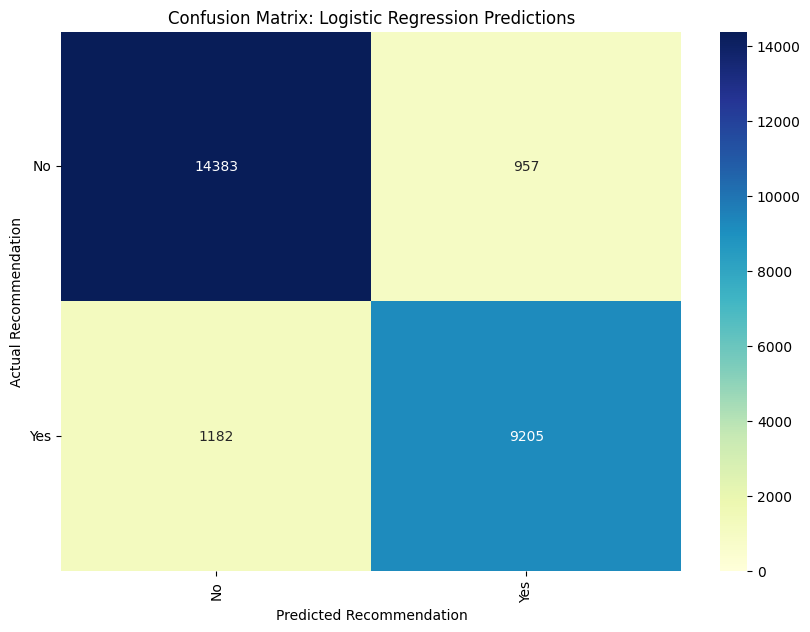

In [173]:
plt.figure(figsize=(10, 7))
sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title('Confusion Matrix Logistic Regression Predictions')
plt.ylabel('Actual Recommendation')
plt.xlabel('Predicted Recommendation')
plt.show()

### LR Heatmap Results

- True Negatives (Top-Left: 14,383)

- True Positives (Bottom-Right: 9,205)

- False Positives (Top-Right: 957)

- False Negatives (Bottom-Left: 1,182)